# ACC Classification with Chronos-2

목표:
- Train: CATSA (ACC)
- Test: Empatica-E4 (ACC)
- 모델: Chronos-2 encoder + lightweight classifier(Logistic Regression)

핵심 아이디어:
- Chronos-2를 **frozen feature extractor**로 사용해 각 윈도우를 임베딩으로 변환
- 분류기는 가볍고 빠른 Logistic Regression으로 학습
- LOSO는 생략하고, CATSA는 45/5 subject split로 내부 검증 후 Empatica-E4 외부 테스트 수행

In [1]:
from pathlib import Path
from typing import Dict, List, Tuple

import random
import numpy as np
import pandas as pd
import torch

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


# ===== 기본 설정 =====
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

BASE_DIR = Path('/home/binghin2/Myproject')
CHRONOS_REPO_SRC = Path('/home/binghin2/Chronos/chronos-forecasting/src')

CATSA_ROOT = BASE_DIR / 'Dataset' / 'CATSA'
EMPATICA_ROOT = BASE_DIR / 'Dataset' / 'EmpaticaE4Stress' / 'Subjects'
EMPATICA_SUBJECTS = [f'subject_{i:02d}' for i in range(1, 7)]

ACC_FS = 32
WINDOW_SEC = 60
STRIDE_SEC = 10
WINDOW_SIZE = ACC_FS * WINDOW_SEC
STRIDE = ACC_FS * STRIDE_SEC

# 속도/메모리 최적화용 (필요 시 값 조절)
MAX_TRAIN_WINDOWS = 25000
MAX_VAL_WINDOWS = 8000
MAX_E4_WINDOWS = 12000

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
TORCH_DTYPE = torch.bfloat16 if torch.cuda.is_available() else torch.float32

print(f'Device: {DEVICE}')
print(f'CATSA root exists: {CATSA_ROOT.exists()} -> {CATSA_ROOT}')
print(f'Empatica root exists: {EMPATICA_ROOT.exists()} -> {EMPATICA_ROOT}')
print(f'Window/Stride (samples): {WINDOW_SIZE}/{STRIDE}')


# ===== CATSA 공통 정의 (CNN&TF 노트북 로직 재사용) =====
TASKS = ['Baseline', 'Logic', 'Nback', 'Stroop', 'Sudoku']
STRESS_TASKS = {'Logic', 'Nback', 'Stroop', 'Sudoku'}


def discover_complete_subjects(dataset_root: Path) -> List[str]:
    subjects: List[str] = []
    for subject_dir in sorted(dataset_root.glob('Sub*'), key=lambda p: int(p.name[3:])):
        if not subject_dir.is_dir():
            continue
        has_all = all((subject_dir / task / 'ACC.csv').exists() for task in TASKS)
        if has_all:
            subjects.append(subject_dir.name)
    return subjects


def read_acc_csv(file_path: Path) -> np.ndarray:
    df = pd.read_csv(file_path)
    expected_cols = ['ACC_X', 'ACC_Y', 'ACC_Z']

    if all(col in df.columns for col in expected_cols):
        values = df[expected_cols].to_numpy(dtype=np.float32)
    else:
        numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
        if len(numeric_cols) < 3:
            raise ValueError(f'ACC must have at least 3 numeric columns in {file_path}')
        values = df[numeric_cols[:3]].to_numpy(dtype=np.float32)

    mask = ~np.any(np.isnan(values), axis=1)
    values = values[mask]
    if len(values) == 0:
        raise ValueError(f'No valid ACC values in {file_path}')
    return values


def sliding_windows(signal: np.ndarray, window_size: int, stride: int) -> np.ndarray:
    if signal.ndim != 2:
        raise ValueError(f'Expected 2D ACC signal [T, C], got shape={signal.shape}')

    if len(signal) < window_size:
        return np.empty((0, signal.shape[1], window_size), dtype=np.float32)

    windows = [signal[i:i + window_size].T for i in range(0, len(signal) - window_size + 1, stride)]
    return np.asarray(windows, dtype=np.float32)


def compute_subject_stats(sub_path: Path) -> Tuple[np.ndarray, np.ndarray]:
    values_list: List[np.ndarray] = []
    for task in TASKS:
        values_list.append(read_acc_csv(sub_path / task / 'ACC.csv'))

    all_values = np.concatenate(values_list, axis=0)
    sub_mean = np.mean(all_values, axis=0).astype(np.float32)
    sub_std = (np.std(all_values, axis=0) + 1e-8).astype(np.float32)
    return sub_mean, sub_std


def build_catsa_arrays(
    dataset_root: Path,
    subject_list: List[str],
    window_size: int,
    stride: int,
) -> Tuple[np.ndarray, np.ndarray]:
    x_chunks: List[np.ndarray] = []
    y_chunks: List[np.ndarray] = []

    for sub in subject_list:
        sub_path = dataset_root / sub
        sub_mean, sub_std = compute_subject_stats(sub_path)

        for task in TASKS:
            raw = read_acc_csv(sub_path / task / 'ACC.csv')
            norm = (raw - sub_mean) / sub_std

            windows = sliding_windows(norm, window_size=window_size, stride=stride)
            if len(windows) == 0:
                continue

            label = 1 if task in STRESS_TASKS else 0
            labels = np.full((len(windows),), label, dtype=np.int64)
            x_chunks.append(windows)
            y_chunks.append(labels)

    if not x_chunks:
        raise ValueError('No CATSA samples generated. Check data files or window settings.')

    x = np.concatenate(x_chunks, axis=0)
    y = np.concatenate(y_chunks, axis=0)
    return x.astype(np.float32), y.astype(np.int64)


# ===== Empatica-E4 라벨링/윈도잉 (CNN&TF Another_dataset 노트북 로직 재사용) =====
def build_protocol_labels(total_len: int, fs: int = 32) -> Tuple[np.ndarray, pd.DataFrame, int]:
    fixed_sec = {
        'rest0': 3 * 60,
        'task1': 10 * 60,
        'rest1': 2 * 60,
        'task2': 5 * 60,
        'rest2': 2 * 60,
        'task3': 3 * 60,
        'rest3': 2 * 60,
        'rest4': 2 * 60,
        'task5': 1 * 60,
        'rest5': 2 * 60,
    }
    fixed = {k: int(v * fs) for k, v in fixed_sec.items()}
    fixed_total = sum(fixed.values())
    task4 = total_len - fixed_total
    if task4 <= 0:
        raise ValueError(f'Total length {total_len/fs:.1f}s is too short for protocol (fixed {fixed_total/fs:.1f}s).')

    labels = np.full((total_len,), -1, dtype=np.int64)
    rows: List[Tuple[str, int, int, int]] = []

    segments = [
        ('rest0', fixed['rest0'], 0),
        ('task1', fixed['task1'], 1),
        ('rest1', fixed['rest1'], -1),
        ('task2', fixed['task2'], 1),
        ('rest2', fixed['rest2'], -1),
        ('task3', fixed['task3'], 1),
        ('rest3', fixed['rest3'], -1),
        ('task4', task4, 1),
        ('rest4', fixed['rest4'], -1),
        ('task5', fixed['task5'], 1),
        ('rest5', fixed['rest5'], -1),
    ]

    cur = 0
    for name, dur, lab in segments:
        end = min(cur + dur, total_len)
        if end > cur:
            labels[cur:end] = lab
            rows.append((name, cur, end, lab))
        cur = end
        if cur >= total_len:
            break

    seg_df = pd.DataFrame(rows, columns=['segment', 'start_sample', 'end_sample', 'label'])
    seg_df['start_sec'] = seg_df['start_sample'] / fs
    seg_df['end_sec'] = seg_df['end_sample'] / fs
    return labels, seg_df, int(task4 / fs)


def normalize_subject_acc(acc: np.ndarray, labels: np.ndarray) -> np.ndarray:
    use_mask = labels >= 0
    if np.any(use_mask):
        mu = np.mean(acc[use_mask], axis=0).astype(np.float32)
        sigma = (np.std(acc[use_mask], axis=0) + 1e-8).astype(np.float32)
    else:
        mu = np.mean(acc, axis=0).astype(np.float32)
        sigma = (np.std(acc, axis=0) + 1e-8).astype(np.float32)
    return (acc - mu) / sigma


def sliding_windows_with_label(
    signal: np.ndarray,
    labels: np.ndarray,
    window_size: int,
    stride: int,
) -> Tuple[np.ndarray, np.ndarray]:
    x_chunks: List[np.ndarray] = []
    y_chunks: List[int] = []

    if len(signal) < window_size:
        return np.empty((0, 3, window_size), dtype=np.float32), np.empty((0,), dtype=np.int64)

    for i in range(0, len(signal) - window_size + 1, stride):
        w_sig = signal[i:i + window_size]
        w_lab = labels[i:i + window_size]
        uniq = np.unique(w_lab)

        if len(uniq) == 1 and uniq[0] in (0, 1):
            x_chunks.append(w_sig.T.astype(np.float32))
            y_chunks.append(int(uniq[0]))

    if len(x_chunks) == 0:
        return np.empty((0, 3, window_size), dtype=np.float32), np.empty((0,), dtype=np.int64)

    x = np.asarray(x_chunks, dtype=np.float32)
    y = np.asarray(y_chunks, dtype=np.int64)
    return x, y


# ===== 샘플 수 제한(속도 최적화) =====
def balanced_subsample(x: np.ndarray, y: np.ndarray, max_samples: int, seed: int = 42) -> Tuple[np.ndarray, np.ndarray]:
    if max_samples <= 0 or len(y) <= max_samples:
        return x, y

    rng = np.random.default_rng(seed)
    idx0 = np.where(y == 0)[0]
    idx1 = np.where(y == 1)[0]

    n0 = min(len(idx0), max_samples // 2)
    n1 = min(len(idx1), max_samples - n0)

    if n1 < max_samples // 2:
        n0 = min(len(idx0), max_samples - n1)
    if n0 < max_samples // 2:
        n1 = min(len(idx1), max_samples - n0)

    sel0 = rng.choice(idx0, size=n0, replace=False) if n0 > 0 else np.array([], dtype=np.int64)
    sel1 = rng.choice(idx1, size=n1, replace=False) if n1 > 0 else np.array([], dtype=np.int64)
    sel = np.concatenate([sel0, sel1])
    rng.shuffle(sel)

    return x[sel], y[sel]

Device: cuda
CATSA root exists: True -> /home/binghin2/Myproject/Dataset/CATSA
Empatica root exists: True -> /home/binghin2/Myproject/Dataset/EmpaticaE4Stress/Subjects
Window/Stride (samples): 1920/320


In [2]:
# ===== CATSA split + window dataset 생성 =====
all_subjects = discover_complete_subjects(CATSA_ROOT)
if len(all_subjects) < 10:
    raise ValueError(f'Need enough CATSA subjects, found only {len(all_subjects)}')

# 참고 노트북 스타일과 맞춰 50명 기준 45/5 split
all_subjects = sorted(all_subjects, key=lambda x: int(x[3:]))[:50]
rng = random.Random(SEED)
val_subjects = sorted(rng.sample(all_subjects, 5), key=lambda x: int(x[3:]))
train_subjects = sorted([s for s in all_subjects if s not in val_subjects], key=lambda x: int(x[3:]))

print(f'Train subjects ({len(train_subjects)}): {train_subjects}')
print(f'Val subjects   ({len(val_subjects)}): {val_subjects}')

x_train_raw, y_train = build_catsa_arrays(
    CATSA_ROOT,
    train_subjects,
    window_size=WINDOW_SIZE,
    stride=STRIDE,
)
x_val_raw, y_val = build_catsa_arrays(
    CATSA_ROOT,
    val_subjects,
    window_size=WINDOW_SIZE,
    stride=STRIDE,
)

# Empatica-E4 test set 생성
x_e4_list: List[np.ndarray] = []
y_e4_list: List[np.ndarray] = []

for sub in EMPATICA_SUBJECTS:
    acc_path = EMPATICA_ROOT / sub / 'ACC.csv'
    if not acc_path.exists():
        print(f'[WARN] Missing {acc_path}, skip.')
        continue

    acc = read_acc_csv(acc_path)
    labels, _, _ = build_protocol_labels(total_len=len(acc), fs=ACC_FS)
    acc_norm = normalize_subject_acc(acc, labels)

    x_sub, y_sub = sliding_windows_with_label(
        acc_norm,
        labels,
        window_size=WINDOW_SIZE,
        stride=STRIDE,
    )
    if len(y_sub) == 0:
        print(f'[WARN] No valid windows for {sub}')
        continue

    x_e4_list.append(x_sub)
    y_e4_list.append(y_sub)

if len(x_e4_list) == 0:
    raise ValueError('No valid Empatica windows generated.')

x_e4_raw = np.concatenate(x_e4_list, axis=0).astype(np.float32)
y_e4 = np.concatenate(y_e4_list, axis=0).astype(np.int64)

# 속도 최적화를 위한 balanced subsampling
x_train_raw, y_train = balanced_subsample(x_train_raw, y_train, MAX_TRAIN_WINDOWS, seed=SEED)
x_val_raw, y_val = balanced_subsample(x_val_raw, y_val, MAX_VAL_WINDOWS, seed=SEED + 1)
x_e4_raw, y_e4 = balanced_subsample(x_e4_raw, y_e4, MAX_E4_WINDOWS, seed=SEED + 2)

print('\n=== Window dataset summary ===')
print(f'CATSA train: {x_train_raw.shape}, labels={np.bincount(y_train)}')
print(f'CATSA val  : {x_val_raw.shape}, labels={np.bincount(y_val)}')
print(f'Empatica   : {x_e4_raw.shape}, labels={np.bincount(y_e4)}')

Train subjects (45): ['Sub1', 'Sub3', 'Sub4', 'Sub5', 'Sub6', 'Sub7', 'Sub9', 'Sub10', 'Sub11', 'Sub12', 'Sub13', 'Sub14', 'Sub15', 'Sub16', 'Sub17', 'Sub20', 'Sub21', 'Sub22', 'Sub23', 'Sub24', 'Sub26', 'Sub27', 'Sub28', 'Sub29', 'Sub30', 'Sub31', 'Sub32', 'Sub33', 'Sub34', 'Sub35', 'Sub36', 'Sub37', 'Sub38', 'Sub40', 'Sub41', 'Sub42', 'Sub43', 'Sub45', 'Sub46', 'Sub47', 'Sub48', 'Sub49', 'Sub50', 'Sub52', 'Sub53']
Val subjects   (5): ['Sub2', 'Sub8', 'Sub18', 'Sub44', 'Sub51']

=== Window dataset summary ===
CATSA train: (2925, 3, 1920), labels=[ 585 2340]
CATSA val  : (325, 3, 1920), labels=[ 65 260]
Empatica   : (780, 3, 1920), labels=[ 78 702]


In [3]:
# ===== Chronos-2 로드 및 임베딩 추출 =====
import sys
if str(CHRONOS_REPO_SRC) not in sys.path:
    sys.path.insert(0, str(CHRONOS_REPO_SRC))

from chronos import Chronos2Pipeline

MODEL_ID = 'amazon/chronos-2'

pipeline = Chronos2Pipeline.from_pretrained(
    MODEL_ID,
    device_map='cuda' if torch.cuda.is_available() else 'cpu',
    torch_dtype=TORCH_DTYPE,
)
chronos_model = pipeline.model
chronos_model.eval()

print(f'Loaded Chronos-2 from: {MODEL_ID}')
print(f'Model dim: {chronos_model.model_dim}')
print(f'Model context length: {pipeline.model_context_length}')


@torch.no_grad()
def encode_windows_chronos2(
    x_windows: np.ndarray,
    model: torch.nn.Module,
    batch_samples: int = 32,
) -> np.ndarray:
    """
    x_windows: [N, 3, W]
    return:    [N, D]  (Chronos-2 encoder pooled embedding)
    """
    if x_windows.ndim != 3 or x_windows.shape[1] != 3:
        raise ValueError(f'Expected [N, 3, W], got {x_windows.shape}')

    features: List[np.ndarray] = []

    for s in range(0, len(x_windows), batch_samples):
        chunk = x_windows[s:s + batch_samples]  # [B, 3, W]
        bsz, ch, win = chunk.shape

        # 각 sample의 3축을 하나의 group으로 묶어 Chronos-2가 채널 간 정보를 함께 보도록 구성
        context = torch.from_numpy(chunk.reshape(bsz * ch, win)).to(device=DEVICE, dtype=torch.float32)
        group_ids = torch.arange(bsz, device=DEVICE).repeat_interleave(ch)

        encoder_outputs, _, _, num_context_patches = model.encode(
            context=context,
            group_ids=group_ids,
            num_output_patches=1,
        )

        hidden = encoder_outputs.last_hidden_state
        if hidden is None:
            raise RuntimeError('Chronos-2 encoder returned no hidden states.')

        hidden = hidden[:, :num_context_patches, :]  # [B*3, P, D]
        hidden = hidden.view(bsz, ch, num_context_patches, -1).mean(dim=(1, 2))  # [B, D]
        hidden = hidden.to(dtype=torch.float32)
        features.append(hidden.detach().cpu().numpy())

    return np.concatenate(features, axis=0)


print('Extracting Chronos-2 embeddings...')
X_train = encode_windows_chronos2(x_train_raw, chronos_model, batch_samples=32)
X_val = encode_windows_chronos2(x_val_raw, chronos_model, batch_samples=32)
X_e4 = encode_windows_chronos2(x_e4_raw, chronos_model, batch_samples=32)

print('Embeddings ready:')
print(f'X_train: {X_train.shape}')
print(f'X_val  : {X_val.shape}')
print(f'X_e4   : {X_e4.shape}')

/home/binghin2/miniconda3/envs/myenv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
`torch_dtype` is deprecated! Use `dtype` instead!
`torch_dtype` is deprecated! Use `dtype` instead!


Loaded Chronos-2 from: amazon/chronos-2
Model dim: 768
Model context length: 8192
Extracting Chronos-2 embeddings...
Embeddings ready:
X_train: (2925, 768)
X_val  : (325, 768)
X_e4   : (780, 768)


In [4]:
# ===== 분류기 학습(CATSA) + 외부 테스트(Empatica-E4) =====
clf = Pipeline(
    [
        ('scaler', StandardScaler()),
        (
            'lr',
            LogisticRegression(
                max_iter=2000,
                class_weight='balanced',
                solver='lbfgs',
                random_state=SEED,
                n_jobs=-1,
            ),
        ),
    ]
)

clf.fit(X_train, y_train)


def evaluate_split(name: str, y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)

    print(f'\n=== {name} ===')
    print(f'Accuracy : {acc:.4f}')
    print(f'F1       : {f1:.4f}')
    print(f'Precision: {prec:.4f}')
    print(f'Recall   : {rec:.4f}')
    print('Confusion Matrix [rows=true, cols=pred]')
    print(confusion_matrix(y_true, y_pred))
    print(classification_report(y_true, y_pred, target_names=['Non-stress', 'Stress'], zero_division=0))

    return {
        'accuracy': float(acc),
        'f1': float(f1),
        'precision': float(prec),
        'recall': float(rec),
    }


y_pred_val = clf.predict(X_val)
y_pred_e4 = clf.predict(X_e4)

val_metrics = evaluate_split('CATSA Validation (5 subjects)', y_val, y_pred_val)
e4_metrics = evaluate_split('Empatica-E4 External Test', y_e4, y_pred_e4)

summary_df = pd.DataFrame(
    [
        {'split': 'CATSA_val', **val_metrics},
        {'split': 'Empatica_E4_test', **e4_metrics},
    ]
)

print('\n=== Summary ===')
display(summary_df)
summary_df


=== CATSA Validation (5 subjects) ===
Accuracy : 0.5723
F1       : 0.7024
Precision: 0.7923
Recall   : 0.6308
Confusion Matrix [rows=true, cols=pred]
[[ 22  43]
 [ 96 164]]
              precision    recall  f1-score   support

  Non-stress       0.19      0.34      0.24        65
      Stress       0.79      0.63      0.70       260

    accuracy                           0.57       325
   macro avg       0.49      0.48      0.47       325
weighted avg       0.67      0.57      0.61       325


=== Empatica-E4 External Test ===
Accuracy : 0.9103
F1       : 0.9513
Precision: 0.9305
Recall   : 0.9729
Confusion Matrix [rows=true, cols=pred]
[[ 27  51]
 [ 19 683]]
              precision    recall  f1-score   support

  Non-stress       0.59      0.35      0.44        78
      Stress       0.93      0.97      0.95       702

    accuracy                           0.91       780
   macro avg       0.76      0.66      0.69       780
weighted avg       0.90      0.91      0.90       780


=

,split,accuracy,f1,precision,recall
0,CATSA_val,0.572308,0.702355,0.792271,0.630769
1,Empatica_E4_test,0.910256,0.951253,0.930518,0.972934


,split,accuracy,f1,precision,recall
0,CATSA_val,0.572308,0.702355,0.792271,0.630769
1,Empatica_E4_test,0.910256,0.951253,0.930518,0.972934


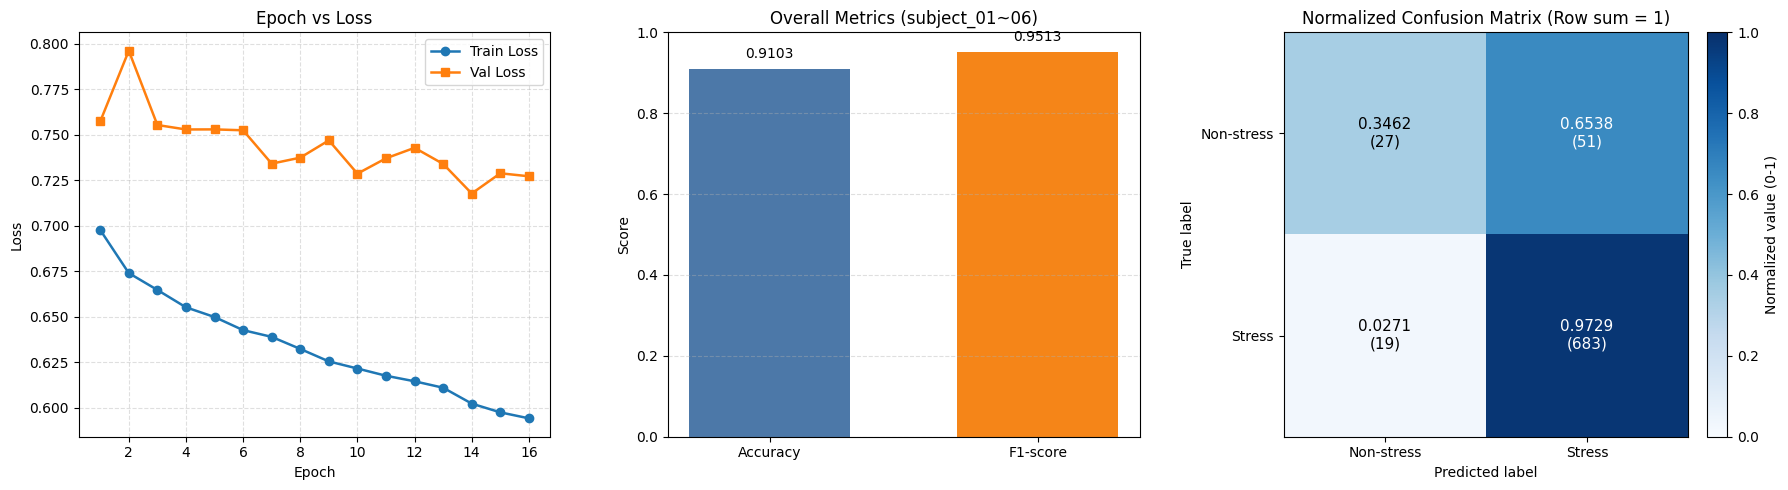

In [5]:
# ===== 3-panel 시각화: Epoch-Loss / Metrics / Confusion Matrix =====
import matplotlib.pyplot as plt
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset


def train_linear_probe_history(
    X_train_np: np.ndarray,
    y_train_np: np.ndarray,
    X_val_np: np.ndarray,
    y_val_np: np.ndarray,
    epochs: int = 16,
    batch_size: int = 256,
    lr: float = 1e-3,
) -> Dict[str, List[float]]:
    """임베딩 위에 선형 분류기를 짧게 학습해 epoch별 train/val loss를 기록한다."""
    scaler_lp = StandardScaler()
    X_train_s = scaler_lp.fit_transform(X_train_np).astype(np.float32)
    X_val_s = scaler_lp.transform(X_val_np).astype(np.float32)

    train_ds = TensorDataset(
        torch.from_numpy(X_train_s),
        torch.from_numpy(y_train_np.astype(np.float32)),
    )
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

    x_val_t = torch.from_numpy(X_val_s).to(DEVICE)
    y_val_t = torch.from_numpy(y_val_np.astype(np.float32)).to(DEVICE)

    model_lp = nn.Linear(X_train_s.shape[1], 1).to(DEVICE)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model_lp.parameters(), lr=lr)

    hist_train: List[float] = []
    hist_val: List[float] = []

    for _ in range(epochs):
        model_lp.train()
        running_loss = 0.0
        seen = 0

        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad(set_to_none=True)
            logits = model_lp(xb).squeeze(1)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            running_loss += float(loss.item()) * xb.size(0)
            seen += xb.size(0)

        train_loss = running_loss / max(seen, 1)

        model_lp.eval()
        with torch.no_grad():
            val_logits = model_lp(x_val_t).squeeze(1)
            val_loss = float(criterion(val_logits, y_val_t).item())

        hist_train.append(train_loss)
        hist_val.append(val_loss)

    return {
        'train_loss': hist_train,
        'val_loss': hist_val,
    }


# Cell 5 실행 전이라면 예측 생성
if 'y_pred_e4' not in globals():
    y_pred_e4 = clf.predict(X_e4)

# 1) Epoch vs Loss (임베딩 기반 linear probe)
history_lp = train_linear_probe_history(X_train, y_train, X_val, y_val, epochs=16, batch_size=256, lr=1e-3)
epochs = np.arange(1, len(history_lp['train_loss']) + 1)

# 2) Overall metrics (Empatica-E4)
acc_e4 = accuracy_score(y_e4, y_pred_e4)
f1_e4 = f1_score(y_e4, y_pred_e4, zero_division=0)

# 3) Confusion matrix (Empatica-E4)
cm = confusion_matrix(y_e4, y_pred_e4)
cm_norm = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1)
class_names = ['Non-stress', 'Stress']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Epoch vs Loss
axes[0].plot(epochs, history_lp['train_loss'], marker='o', linewidth=1.8, label='Train Loss')
axes[0].plot(epochs, history_lp['val_loss'], marker='s', linewidth=1.8, label='Val Loss')
axes[0].set_title('Epoch vs Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True, linestyle='--', alpha=0.4)
axes[0].legend()

# Panel 2: Accuracy / F1
metrics = ['Accuracy', 'F1-score']
values = [acc_e4, f1_e4]
colors = ['#4C78A8', '#F58518']
bars = axes[1].bar(metrics, values, color=colors, width=0.6)
axes[1].set_ylim(0, 1)
axes[1].set_title('Overall Metrics (subject_01~06)')
axes[1].set_ylabel('Score')
axes[1].grid(axis='y', linestyle='--', alpha=0.4)
for bar, v in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, v + 0.02, f'{v:.4f}', ha='center', va='bottom', fontsize=10)

# Panel 3: Normalized confusion matrix
im = axes[2].imshow(cm_norm, interpolation='nearest', cmap='Blues', vmin=0, vmax=1)
axes[2].set_title('Normalized Confusion Matrix (Row sum = 1)')
axes[2].set_xlabel('Predicted label')
axes[2].set_ylabel('True label')
axes[2].set_xticks(np.arange(len(class_names)))
axes[2].set_yticks(np.arange(len(class_names)))
axes[2].set_xticklabels(class_names)
axes[2].set_yticklabels(class_names)

threshold = cm_norm.max() / 2 if cm_norm.size else 0.5
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        axes[2].text(
            j,
            i,
            f'{cm_norm[i, j]:.4f}\n({cm[i, j]})',
            ha='center',
            va='center',
            color='white' if cm_norm[i, j] > threshold else 'black',
            fontsize=11,
        )

cbar = fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
cbar.set_label('Normalized value (0-1)')

plt.tight_layout()
plt.show()